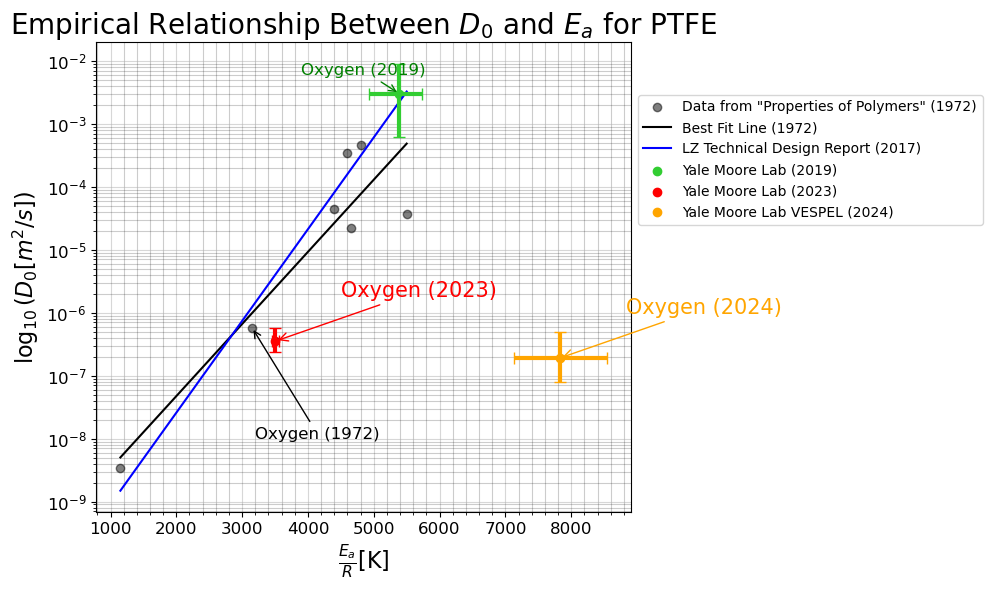

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize = (8, 6))

# boltzman = 8.61733E-5
# Conductance = 20500  # cm^3/s calculated from calibrated leak
# Concentration = 212.8 # calculated as mbar partial pressure of oxygen at 1 atm

"""
    Meta-study data from Krevelen's "Properties of Polymers" (1972), pp. 666-667, Table 18.6, Polymer: Poly(tetrafluoroethylene), Diffusing Gas: O2
"""
D_0_Polymer = [0.44e-4, 4.55e-4, 3.5e-4, 0.0058e-4, 0.22e-4, 3.41e-9, 0.37e-4] #in m^2/s
E_a_Polymer = [4400, 4800, 4600, 3150, 4650, 1150, 5500] #in K

# Take the logarithm (base 10) of the y-values
log_D_0_Polymer = np.log10(D_0_Polymer)

# Perform linear regression on the transformed data
slope, intercept = np.polyfit(E_a_Polymer, log_D_0_Polymer, deg=1)

# Plot the scatter points in a semilog plot
plt.semilogy(E_a_Polymer, D_0_Polymer, 'ko', label='Data from "Properties of Polymers" (1972)', alpha=0.5)

# Generate the line values for plotting
E_a_line = np.linspace(min(E_a_Polymer), max(E_a_Polymer), num=100)
log_D_0_line = slope * E_a_line + intercept

# Convert the logarithmic y-values back to the original scale
D_0_line = 10 ** log_D_0_line

# Plot the fitted line in the semilog plot
plt.semilogy(E_a_line, D_0_line, 'k-', label='Best Fit Line (1972)')

# Add an arrow and label to the specified data point
plt.annotate('Oxygen (1972)', xy=(3150, 0.0058e-4), xytext=(3200, 0.0001e-4),
             arrowprops=dict(facecolor='red', arrowstyle='->'), fontsize=12)

"""
    LZ (2017) measurements: https://arxiv.org/pdf/1703.09144.pdf, Page 187, Table 6.10.1, 

    LZ collaboration reports D(298 K) for O2 diffusing from PTFE  
    
    From this we relate D_o and E_a using the Arrhenius relation D = Do * exp(-E_a / R * 298)
    
    # D = [15.1e-12, 31.4e-12, 5.6e-12, 0.8e-12, 16.8e-12, 1270e-12] #[N_2, O_2, Kr, Xe, Ar, He] in m^2/sec (multiplied by 1e-4 to convert from cm^2/sec)
    # D_err = [0.3e-12, 0.6e-12, 0.1e-12, 0.02e-12, 0.3e-12, 25e-12]
"""

# Constants
T = 298  # Temperature (K)
# R = 8.314  # Gas constant (J/(mol*K))

#Measured Data
D_298 = 31.4e-12  # Diffusion coefficient at 298 K
# D_298_error = 0.6e-12  # Uncertainty in diffusion coefficient at 298 K
log_D_298 = np.log10(D_298)

# Generate E_a/R values within the desired range
E_a_over_R_values = np.linspace(1150, 5500, 10000)

# Calculate corresponding D₀ values
D0_values = 10 ** (log_D_298 + (E_a_over_R_values / (T * np.log(10))))

# Plotting LZ (2017) Data
plt.semilogy(E_a_over_R_values, D0_values, label = 'LZ Technical Design Report (2017)', color = 'b')

"""
    Moore Lab measurements (2019, 2023)
"""
# Plug in our data, x is the activation energy, x_err is the errors in the activation energy
x= [5387.37, 3505.31, 7827.28] #[2019 E_a data, 2023 E_a data, 2024 D_o VESPEL]
x_err = [[[464.43],[348.32]], [[np.abs(3505.31-3448.13)], [np.abs(3505.31-3562.42)]], [[np.abs(7827.28-7130.23)], [np.abs(7827.28-8537.95)]]] #activation energy error bars

D_0 = [30.14e-4, 35.31e-8, 0.001905e-4] ##[2019 D_o data, 2023 D_o data, 2024 D_o VESPEL]
D_0_err = [[[24e-4],[60e-4]], [[np.abs(35.31e-8-23.33e-8)],[np.abs(35.31e-8-57.23e-8)]], [[np.abs(0.001905e-4-0.0007874e-4)], [np.abs(0.001905e-4-0.005020e-4)]]] #diffusion coefficient error bars

# Plotting Stockroom PTFE (2019) Data
plt.scatter(x[0],D_0[0],c='limegreen',label='Yale Moore Lab (2019)')
plt.errorbar(x[0],D_0[0],yerr=D_0_err[0], xerr=x_err[0], linestyle="None", elinewidth=3, capsize=4, c='limegreen')
plt.annotate('Oxygen (2019)', xy=(x[0], D_0[0]), xytext=(x[0] - 1500, D_0[0]*2),
             arrowprops=dict(facecolor='gold', arrowstyle='->', edgecolor='green'), color='green', fontsize=12)

# Plotting Stockroom PTFE (2023) Data
plt.scatter(x[1],D_0[1],c='r',label='Yale Moore Lab (2023)')
plt.errorbar(x[1],D_0[1],yerr=D_0_err[1], xerr=x_err[1], linestyle="None", elinewidth=3, capsize=4, c='r')
plt.annotate('Oxygen (2023)', xy=(x[1], D_0[1]), xytext=(x[1] + 1000, D_0[1] * 5),
             arrowprops=dict(facecolor='red', arrowstyle='->', edgecolor='red'), color='red', fontsize=15)

# Plotting Stockroom VESPEL (2024) Data
plt.scatter(x[2],D_0[2],c='orange',label='Yale Moore Lab VESPEL (2024)')
plt.errorbar(x[2],D_0[2],yerr=D_0_err[2], xerr=x_err[2], linestyle="None", elinewidth=3, capsize=4, c='orange')
plt.annotate('Oxygen (2024)', xy=(x[2], D_0[2]), xytext=(x[2] + 1000, D_0[2] * 5),
             arrowprops=dict(facecolor='red', arrowstyle='->', edgecolor='orange'), color='orange', fontsize=15)

"""
    Plotting 
"""

plt.title(r"Empirical Relationship Between $D_0$ and $E_a$ for PTFE", fontsize = 20)
ax1 = plt.gca()
ax1.set_yscale('log')
plt.legend(loc="best")
ax1.set_xlabel(r'$\frac{E_a}{R}$[K]', fontsize = 16)
ax1.set_ylabel(r"$\log_{10}(D_0 [m^2/s])$", fontsize = 16)
ax1.grid(which='both')
ax1.grid(which='minor', color='k', linestyle='-', alpha=0.2)
ax1.grid(which='major', alpha=0.5)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.minorticks_on()
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.75))
plt.show()